# Red Sideband Swap Between `|f,0>` and `|g,1>`


This notebook rewrites `examples/sideband_swap_demo.py` as a tutorial for the effective sideband interface. We use a three-level transmon, a storage mode, and a red sideband drive that swaps population between `|f,0>` and `|g,1>`.

The physical objective is the canonical bosonic-transfer primitive used in many cQED protocols: move one excitation from the transmon ladder into the cavity while staying within an effective rotating-wave sideband model.


## Imports


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import (
    DispersiveTransmonCavityModel,
    FrameSpec,
    SequenceCompiler,
    SidebandDriveSpec,
    SimulationConfig,
    build_sideband_pulse,
    carrier_for_transition_frequency,
    simulate_sequence,
)
from tutorials.tutorial_support import GHz, MHz, ns


## Physics / model definition


In [2]:
model = DispersiveTransmonCavityModel(
    omega_c=GHz(5.0),
    omega_q=GHz(6.0),
    alpha=MHz(-220.0),
    chi=MHz(-0.8),
    kerr=0.0,
    n_cav=4,
    n_tr=3,
)
frame = FrameSpec(omega_c_frame=model.omega_c, omega_q_frame=model.omega_q)
g_sb = MHz(8.0)
t_swap = np.pi / (2.0 * g_sb)

initial_state = model.basis_state(2, 0)
target_state = model.basis_state(0, 1)


## Pulse / sequence construction


In [3]:
omega_sb = model.sideband_transition_frequency(
    cavity_level=0,
    lower_level=0,
    upper_level=2,
    sideband="red",
    frame=frame,
)
pulses, drive_ops, pulse_meta = build_sideband_pulse(
    SidebandDriveSpec(mode="storage", lower_level=0, upper_level=2, sideband="red"),
    duration_s=t_swap,
    amplitude_rad_s=g_sb,
    channel="sb",
    carrier=carrier_for_transition_frequency(omega_sb),
    label="gf_red_sideband",
)
compiled = SequenceCompiler(dt=t_swap / 300.0).compile(pulses, t_end=t_swap)
print("Pulse metadata:", pulse_meta)


Pulse metadata: {'mapping': 'Effective multilevel sideband drive using the structured SidebandDriveSpec target.', 'duration_s': 3.125e-08, 'amplitude_rad_s': 50265482.45743669, 'carrier': 1382300767.579509, 'phase': 0.0, 'envelope': 'square', 'sideband_target': {'mode': 'storage', 'lower_level': 0, 'upper_level': 2, 'sideband': 'red'}}


## Simulation


In [4]:
result = simulate_sequence(
    model,
    compiled,
    initial_state,
    drive_ops,
    config=SimulationConfig(frame=frame, store_states=True),
)

times_ns = np.asarray(compiled.tlist, dtype=float) / ns
p_g1 = np.asarray([abs(target_state.overlap(state)) ** 2 for state in result.states], dtype=float)
p_f0 = np.asarray([abs(initial_state.overlap(state)) ** 2 for state in result.states], dtype=float)

print("Final |g,1> population:", float(p_g1[-1]))
print("Final |f,0> population:", float(p_f0[-1]))


Final |g,1> population: 0.9999968425958902
Final |f,0> population: 3.1574041099122913e-06


## Analysis / visualization


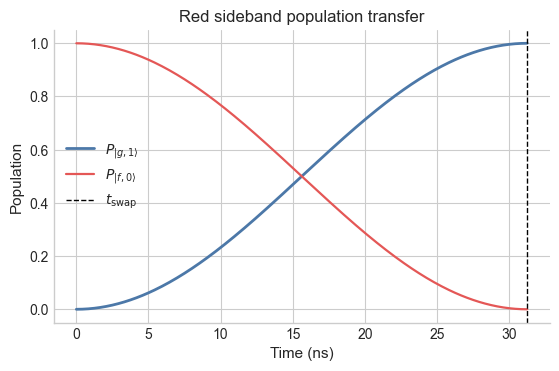

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(times_ns, p_g1, label=r"$P_{|g,1\rangle}$", lw=2.0, color="#4C78A8")
ax.plot(times_ns, p_f0, label=r"$P_{|f,0\rangle}$", lw=1.6, color="#E45756")
ax.axvline(t_swap / ns, color="black", ls="--", lw=1.0, label=r"$t_{\mathrm{swap}}$")
ax.set_xlabel("Time (ns)")
ax.set_ylabel("Population")
ax.set_title("Red sideband population transfer")
ax.legend(loc="best")
plt.show()


## Interpretation


At the swap time, almost all amplitude has moved from `|f,0>` into `|g,1>`. This is the effective `gf` red-sideband primitive that many storage-control protocols build on.

The notebook explicitly computes the rotating-frame sideband transition frequency and then feeds it through `carrier_for_transition_frequency(...)`, which keeps the carrier sign aligned with the project convention.


## Variations / exercises


- Shorten the pulse to observe under-rotation and Rabi-like oscillations.
- Add `NoiseSpec(...)` to see how transmon relaxation or cavity decay spoils the swap.
- Repeat the calculation with a different initial storage Fock level and compare the matrix-element scaling.
